Reading scan data from: d:\eBATS\data\C0010\C0004R02_PARK25_AC_1D_SCAN.xlsx
Total scan cases: 180
Normal-day cases at T_air,in = 25.0 degC: 36
Feasible cases: 18
Infeasible cases: 18
Pareto-optimal cases: 18
Feasible dominated cases: 0

Selected design:
V_air = 1.50 m/s
s_gap = 2.0 mm
Tmax = 44.787 degC
DeltaTmax = 3.508 degC
Efan = 1.370 kJ
Bottom-plate mass = 0.596 kg


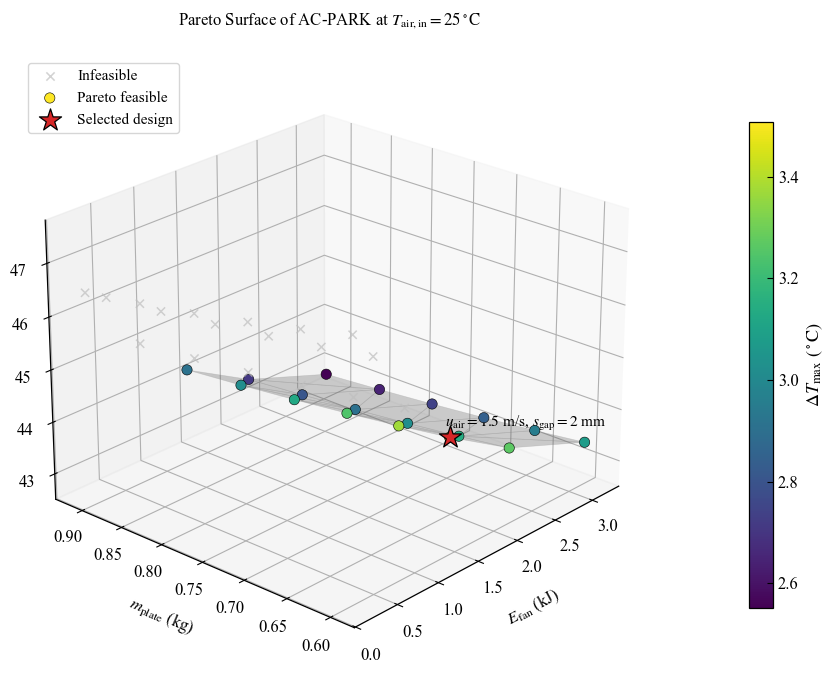


Saved PNG: d:\eBATS\out\C0010\C0010_PARK25_AC_Pareto_surface.png
Saved PDF: d:\eBATS\out\C0010\C0010_PARK25_AC_Pareto_surface.pdf


In [1]:
# Plot the Pareto surface for the AC-PARK parametric scan.

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation

# ============================================================
# File settings
# ============================================================

PROJECT_ROOT = os.path.abspath('../..')
CASE_ID = 'C0010'
SOURCE_FILE_NAME = 'C0004R02_PARK25_AC_1D_SCAN.xlsx'
file_name = os.path.join(PROJECT_ROOT, 'data', CASE_ID, SOURCE_FILE_NAME)
output_dir = os.path.join(PROJECT_ROOT, 'out', CASE_ID)

# Fallback for the current local project path.
if not os.path.exists(file_name):
    PROJECT_ROOT = r'D:\eBATS'
    file_name = os.path.join(PROJECT_ROOT, 'data', CASE_ID, SOURCE_FILE_NAME)
    output_dir = os.path.join(PROJECT_ROOT, 'out', CASE_ID)

if not os.path.exists(file_name):
    raise FileNotFoundError(f'Cannot find scan file: {file_name}')

os.makedirs(output_dir, exist_ok=True)
print(f'Reading scan data from: {file_name}')

# ============================================================
# Read scan results
# ============================================================

data = pd.read_excel(file_name)
required_columns = ['case_id', 'V_air_m_s', 'T_air_in_C', 's_gap_mm', 'E_fan_cumulative_J', 'Tmax_mission_C', 'DeltaT_mission_max_C', 'm_bottom_plate_kg']
missing_columns = [column for column in required_columns if column not in data.columns]

if missing_columns:
    raise KeyError(f'Missing required columns: {missing_columns}')

print(f'Total scan cases: {len(data)}')

# ============================================================
# Normal-day condition
# ============================================================

T_air_normal = 25.0
data = data[np.isclose(data['T_air_in_C'], T_air_normal)].copy()
data['Efan_kJ'] = data['E_fan_cumulative_J'] / 1000.0
print(f'Normal-day cases at T_air,in = {T_air_normal:.1f} degC: {len(data)}')

# ============================================================
# Thermal constraints
# ============================================================

Tmax_limit = 45.0
DeltaT_limit = 5.0
data['feasible'] = (data['Tmax_mission_C'] <= Tmax_limit) & (data['DeltaT_mission_max_C'] <= DeltaT_limit)
data_feasible = data[data['feasible']].copy()
data_infeasible = data[~data['feasible']].copy()
print(f'Feasible cases: {len(data_feasible)}')
print(f'Infeasible cases: {len(data_infeasible)}')

# ============================================================
# Pareto identification
# All four objectives are minimized:
# 1. Tmax
# 2. DeltaTmax
# 3. Fan energy
# 4. Bottom-plate mass
# ============================================================

pareto_objectives = ['Tmax_mission_C', 'DeltaT_mission_max_C', 'Efan_kJ', 'm_bottom_plate_kg']

def get_pareto_mask(values):
    values = np.asarray(values, dtype=float)
    pareto_mask = np.ones(values.shape[0], dtype=bool)
    for i in range(values.shape[0]):
        dominated_by_other = np.all(values <= values[i], axis=1) & np.any(values < values[i], axis=1)
        dominated_by_other[i] = False
        if np.any(dominated_by_other):
            pareto_mask[i] = False
    return pareto_mask

pareto_mask = get_pareto_mask(data_feasible[pareto_objectives].to_numpy())
data_pareto = data_feasible.loc[pareto_mask].copy()
data_nonpareto = data_feasible.loc[~pareto_mask].copy()
print(f'Pareto-optimal cases: {len(data_pareto)}')
print(f'Feasible dominated cases: {len(data_nonpareto)}')

# ============================================================
# Selected AC-PARK design
# ============================================================

selected_V_air = 1.50
selected_s_gap = 2.0
selected_case = data[np.isclose(data['V_air_m_s'], selected_V_air) & np.isclose(data['s_gap_mm'], selected_s_gap)].copy()

if len(selected_case) != 1:
    raise ValueError('The selected AC-PARK design was not uniquely found.')

selected_case = selected_case.iloc[0]
print()
print('Selected design:')
print(f"V_air = {selected_case['V_air_m_s']:.2f} m/s")
print(f"s_gap = {selected_case['s_gap_mm']:.1f} mm")
print(f"Tmax = {selected_case['Tmax_mission_C']:.3f} degC")
print(f"DeltaTmax = {selected_case['DeltaT_mission_max_C']:.3f} degC")
print(f"Efan = {selected_case['Efan_kJ']:.3f} kJ")
print(f"Bottom-plate mass = {selected_case['m_bottom_plate_kg']:.3f} kg")

# ============================================================
# Plot settings
# ============================================================

font_size = 12
plt.rcParams.update({'font.family': 'Times New Roman', 'mathtext.fontset': 'stix', 'font.size': font_size, 'axes.labelsize': font_size, 'axes.titlesize': font_size, 'xtick.labelsize': font_size, 'ytick.labelsize': font_size, 'axes.linewidth': 0.9, 'xtick.direction': 'in', 'ytick.direction': 'in', 'xtick.major.width': 0.8, 'ytick.major.width': 0.8, 'xtick.major.size': 4, 'ytick.major.size': 4, 'axes.unicode_minus': False})

# ============================================================
# Create Pareto surface
# x-axis : cumulative fan energy
# y-axis : bottom-plate mass
# z-axis : maximum battery temperature
# color  : maximum battery temperature difference
# ============================================================

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

# Infeasible designs.
ax.scatter(data_infeasible['Efan_kJ'], data_infeasible['m_bottom_plate_kg'], data_infeasible['Tmax_mission_C'], color='0.75', marker='x', s=35, linewidth=1.1, alpha=0.70, label='Infeasible')

# Feasible but dominated designs, if any.
if len(data_nonpareto) > 0:
    ax.scatter(data_nonpareto['Efan_kJ'], data_nonpareto['m_bottom_plate_kg'], data_nonpareto['Tmax_mission_C'], facecolors='none', edgecolors='0.45', marker='o', s=40, linewidth=1.0, alpha=0.8, label='Feasible dominated')

# Pareto surface.
if len(data_pareto) >= 3:
    triangulation = Triangulation(data_pareto['Efan_kJ'].to_numpy(), data_pareto['m_bottom_plate_kg'].to_numpy())
    ax.plot_trisurf(triangulation, data_pareto['Tmax_mission_C'].to_numpy(), color='0.75', alpha=0.28, edgecolor='0.55', linewidth=0.45, antialiased=True)

# Pareto points; color represents DeltaTmax.
scatter_pareto = ax.scatter(data_pareto['Efan_kJ'], data_pareto['m_bottom_plate_kg'], data_pareto['Tmax_mission_C'], c=data_pareto['DeltaT_mission_max_C'], cmap='viridis', marker='o', s=55, edgecolor='black', linewidth=0.40, depthshade=False, label='Pareto feasible')

# Selected design.
ax.scatter(selected_case['Efan_kJ'], selected_case['m_bottom_plate_kg'], selected_case['Tmax_mission_C'], color='#D62728', edgecolor='black', marker='*', s=280, linewidth=0.9, depthshade=False, label='Selected design')
ax.text(selected_case['Efan_kJ'] + 0.05, selected_case['m_bottom_plate_kg'] + 0.01, selected_case['Tmax_mission_C'] + 0.10, r'$u_{\mathrm{air}}=1.5$ m/s, $s_{\mathrm{gap}}=2$ mm', fontsize=font_size - 1)

# Axis labels.
ax.set_xlabel(r'$E_{\mathrm{fan}}$ (kJ)', labelpad=10)
ax.set_ylabel(r'$m_{\mathrm{plate}}$ (kg)', labelpad=10)
ax.set_zlabel(r'$T_{\max}$ ($^\circ\mathrm{C}$)', labelpad=10)
ax.set_title(r'Pareto Surface of AC-PARK at $T_{\mathrm{air,in}}=25^\circ\mathrm{C}$', pad=18)

# Colorbar.
colorbar = fig.colorbar(scatter_pareto, ax=ax, pad=0.12, shrink=0.76)
colorbar.set_label(r'$\Delta T_{\max}$ ($^\circ\mathrm{C}$)', fontsize=font_size + 1)

# Legend and view.
ax.legend(loc='upper left', bbox_to_anchor=(0.01, 0.99), fontsize=font_size - 1)
ax.view_init(elev=24, azim=-138)

# ============================================================
# Output
# ============================================================

plt.tight_layout()
png_file = os.path.join(output_dir, 'C0010_PARK25_AC_Pareto_surface.png')
pdf_file = os.path.join(output_dir, 'C0010_PARK25_AC_Pareto_surface.pdf')
plt.savefig(png_file, dpi=600, bbox_inches='tight')
plt.savefig(pdf_file, dpi=600, bbox_inches='tight')
plt.show()
print()
print(f'Saved PNG: {png_file}')
print(f'Saved PDF: {pdf_file}')

